In [1]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.8 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow

# Paste YOUR api_key from the Roboflow snippet
rf = Roboflow(api_key="3z2Esy1uneC7QPaPbQBz")
project = rf.workspace("joseph-nelson").project("plantdoc")
dataset = project.version(4).download("yolov8")

print("✅ Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PlantDoc-4 in yolov8:: 100%|██████████| 5150/5150 [00:01<00:00, 3240.33it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Dataset downloaded to: /content/PlantDoc-4


In [3]:
import os

dataset_path = dataset.location
print("Path:", dataset_path)
print("Contents:", os.listdir(dataset_path))

# Should show: ['train', 'valid', 'test', 'data.yaml']

Path: /content/PlantDoc-4
Contents: ['valid', 'README.dataset.txt', 'data.yaml', 'test', 'README.roboflow.txt', 'train']


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # downloads pretrained COCO weights automatically

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="cropdoc_plantdoc",
    patience=10
)

print("✅ Training complete!")

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PlantDoc-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cropdoc_plantdoc, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, p

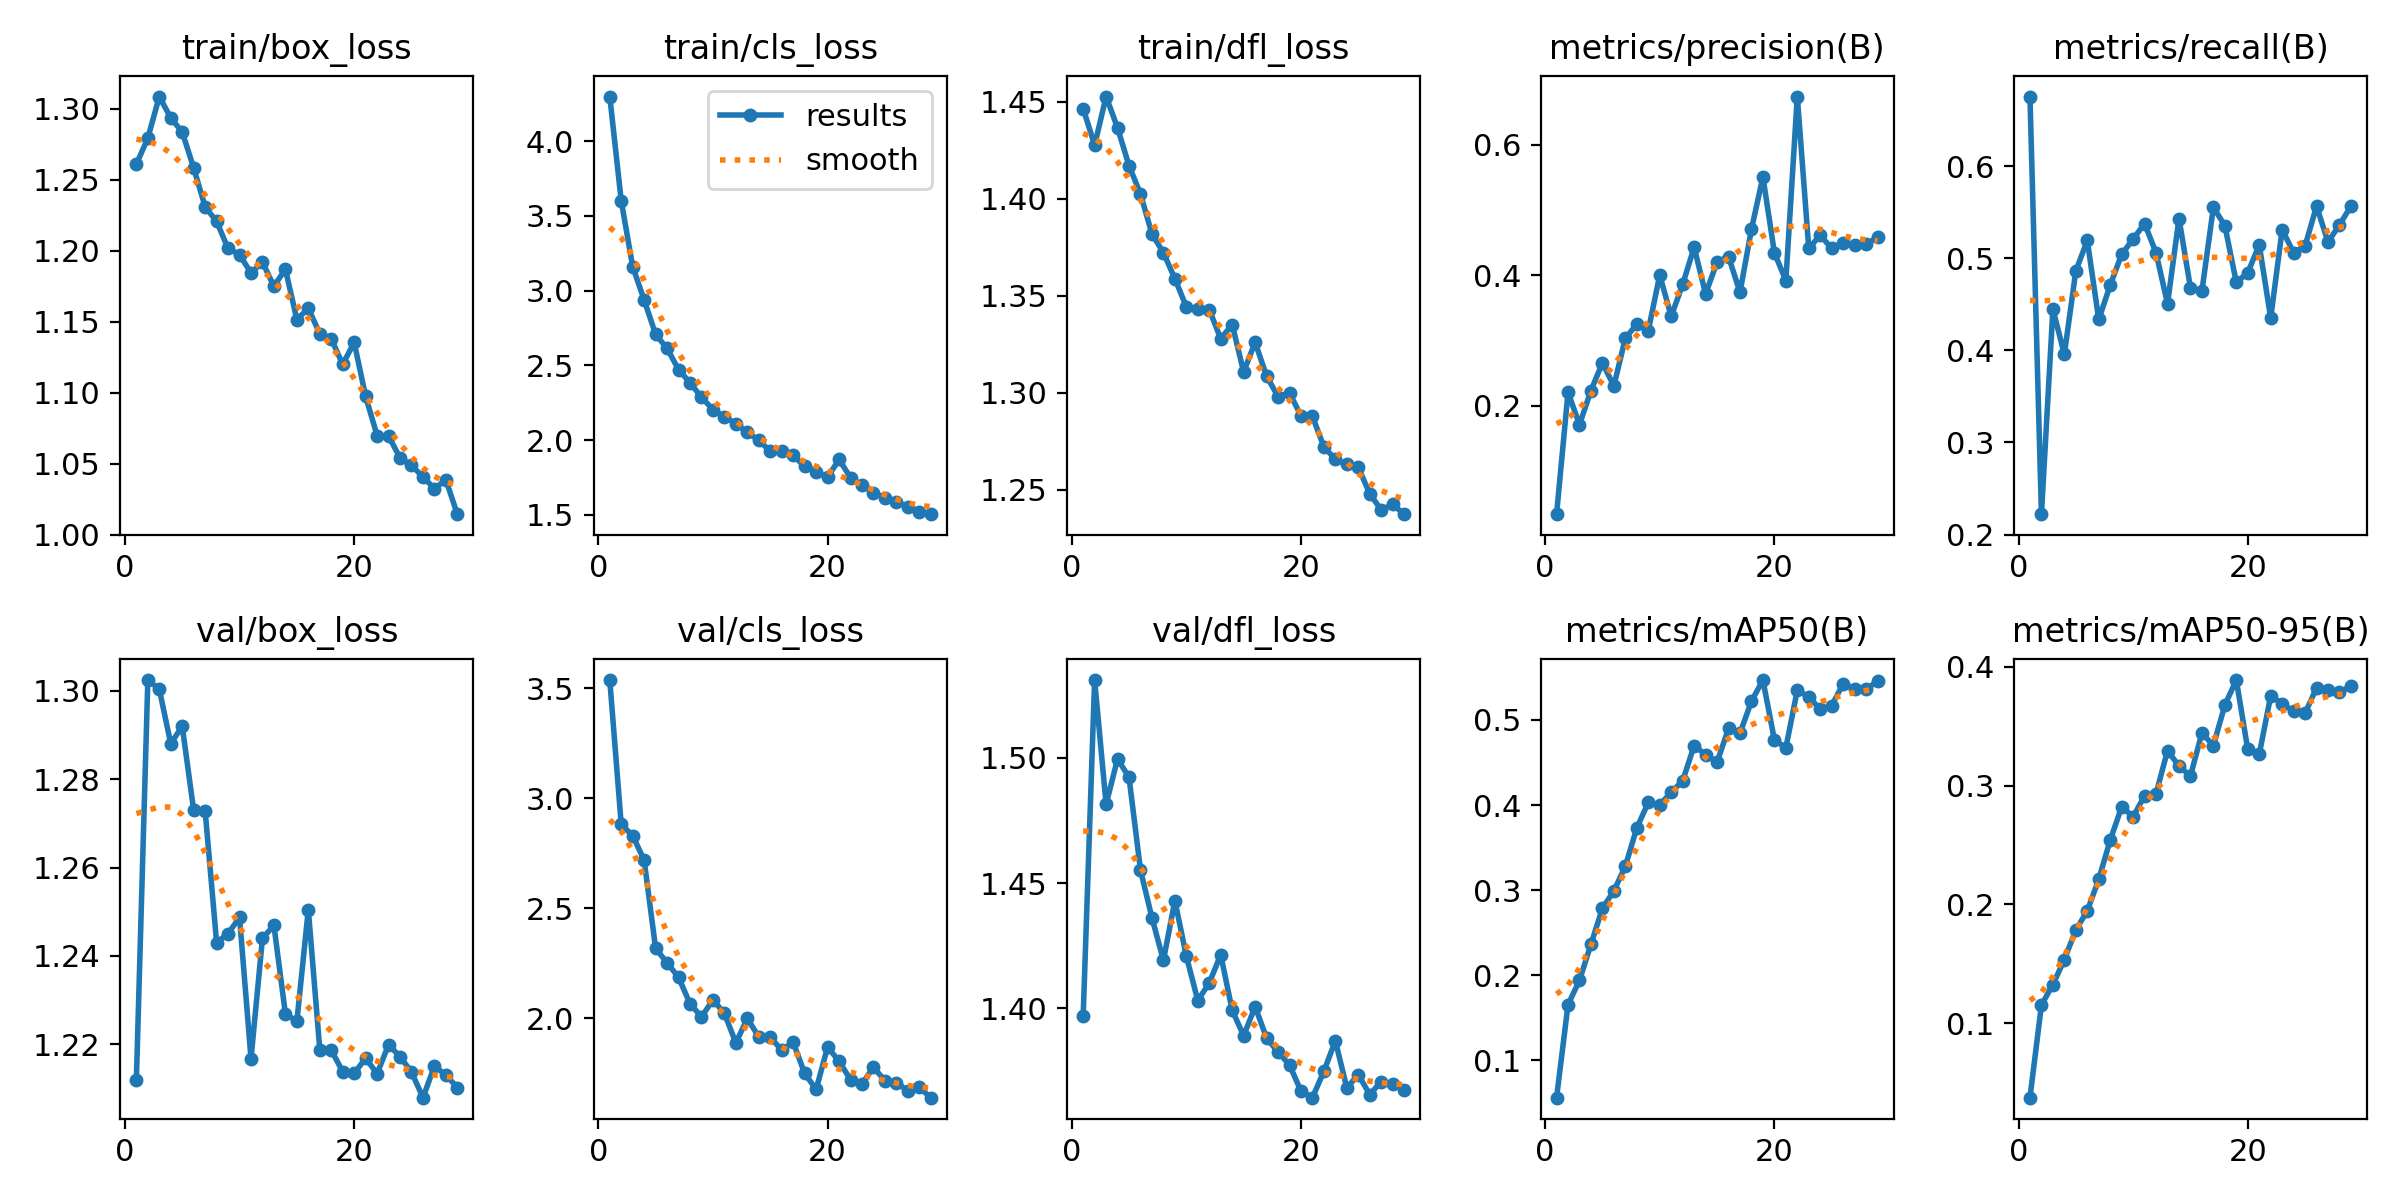

In [5]:
import glob
from IPython.display import Image

results = glob.glob("/content/runs/detect/cropdoc_plantdoc/results.png")
Image(results[0])

In [6]:
from google.colab import files
files.download("/content/runs/detect/cropdoc_plantdoc/weights/best.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>